# Modelo de Barabasi-Albert

Las redes reales no tienen una cantidad fija de nodos, van creciendo con el tiempo. Cuando un nuevo nodo aparece, se conecta con algunos de los ya existentes. La pregunta es, ¿a cuáles nodos es más probable que se conecte el nuevo nodo?

En el caso no dirigido, al agregar un nuevo nodo, éste se conecta con $m$ de los nodos ya existentes. Por lo que su grado inicial es $m\neq 0$. No es necesario añadir una constante. Así que la probabilidad de que un nodo $i$ sea conectado con el nuevo nodo, es proporcional a su grado $k_i$:

$$\Pi(k_i)=\frac{k_i}{\sum_jk_j}$$

# Actividad

In [25]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

SEED = 863

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [26]:
def build_hub_mini_network(G, top_k=10, expand_steps=0):
    # elegir hubs
    ranked_hubs = [node for node, _ in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:top_k]]
    backbone = set(ranked_hubs)

    # unir hubs con caminos cortos
    for i, source in enumerate(ranked_hubs):
        for target in ranked_hubs[i + 1:]:
            backbone.update(nx.shortest_path(G, source=source, target=target))

    # crecer una capa mas
    nodes = set(backbone)
    frontier = set(backbone)
    for _ in range(expand_steps):
        frontier = {neighbor for node in frontier for neighbor in G.neighbors(node)} - nodes
        nodes.update(frontier)

    return G.subgraph(nodes).copy(), ranked_hubs, backbone


def degree_distribution(G):
    # contar grados
    degrees = np.array([degree for _, degree in G.degree()])
    values, counts = np.unique(degrees, return_counts=True)
    return values, counts / counts.sum()


def fit_power_law(G):
    # ajuste en log log
    k, pk = degree_distribution(G)
    mask = k > 0
    alpha, log_c = np.polyfit(np.log(k[mask]), np.log(pk[mask]), 1)
    return float(np.exp(log_c)), float(alpha)


def summarize_graph(G, label):
    # resumir metricas
    C, alpha = fit_power_law(G)
    return {
        "red": label,
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "grado medio": 2 * G.number_of_edges() / G.number_of_nodes(),
        "densidad": nx.density(G),
        "clustering medio": nx.average_clustering(G),
        "distancia media": nx.average_shortest_path_length(G),
        "C": C,
        "alpha": alpha,
    }


def plot_degree_distribution(ax, G, label, color):
    # datos y ajuste
    k, pk = degree_distribution(G)
    C, alpha = fit_power_law(G)
    x_fit = np.linspace(k[k > 0].min(), k.max(), 200)

    ax.scatter(k, pk, s=40, alpha=0.8, color=color, label=f"{label}: datos")
    ax.plot(x_fit, C * x_fit**alpha, "--", lw=2, color=color, label=f"{label}: ${C:.3f}k^{{{alpha:.2f}}}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("grado k")
    ax.set_ylabel("P(k)")
    ax.grid(True, which="both", ls=":", alpha=0.4)
    return C, alpha


def prepare_seed_graph(G):
    # renombrar la semilla
    mapping = {node: idx for idx, node in enumerate(G.nodes())}
    reverse_mapping = {idx: node for node, idx in mapping.items()}
    seed_graph = nx.relabel_nodes(G, mapping, copy=True)
    return seed_graph, mapping, reverse_mapping


def draw_graph(ax, G, title, highlight_nodes=None, annotate_nodes=None):
    # resaltar nodos clave
    highlight_nodes = set(highlight_nodes or [])
    annotate_nodes = list(annotate_nodes or [])
    pos = nx.spring_layout(G, seed=SEED, k=0.7 / np.sqrt(G.number_of_nodes()))
    node_colors = ["tab:orange" if node in highlight_nodes else "#7aa6c2" for node in G.nodes()]
    node_sizes = [30 + 8 * G.degree(node) for node in G.nodes()]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.8, edge_color="#94a3b8")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        linewidths=0.3,
        edgecolors="white",
    )

    # poner etiquetas
    for node in annotate_nodes:
        ax.text(pos[node][0], pos[node][1], str(node), fontsize=9, ha="center", va="center")

    ax.set_title(title)
    ax.axis("off")
    return pos

# 1

- Considera una subred conexa (de preferencia) que contenga a los nodos con mayor grado. Utiliza la subred como red inicial del modelo de Barabasi_Albert y genera aparte una red con la misma cantidad de nodos que la minired con un valor adecuado de $m$.

La red manual del SP500 no es conexa: se separa en un bloque tecnologico y otro de pagos-consumo. Para aplicar el modelo y comparar distancias, primero tomo la componente conexa principal. Dentro de esa componente elijo los 5 nodos de mayor grado, que ya forman una minired conectada y representan el nucleo de empresas ligadas a IA, nube y software.

El valor de $m$ se fija como el entero mas cercano a $\bar{k}/2$ de la minired, porque en el modelo de Barabasi-Albert el grado medio tiende a ser aproximadamente $2m$.


In [27]:
# cargar la red real
from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH"
]

E: List[Tuple[str, str]] = [
    # semiconductores / hardware / computo
    ("MU", "NVDA"),
    ("AVGO", "AAPL"),
    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),
    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),

    # nube / servicios / datos
    ("AMZN", "NFLX"),
    ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"),
    ("AMZN", "PLTR"),
    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"),
    ("MSFT", "PLTR"),
    ("GOOGL", "PLTR"),
    ("ORCL", "PLTR"),

    # pagos / retail / consumo
    ("AAPL", "WMT"), ("AAPL", "COST"),
    ("PG", "WMT"),
    ("BRK.B", "WMT"),
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"),
    ("JPM", "AAPL"),

    # salud
    ("LLY", "AMZN"),
]

G_full = nx.Graph()
G_full.add_nodes_from(V)
G_full.add_edges_from(E)

# usar la componente principal
components = sorted(nx.connected_components(G_full), key=len, reverse=True)
G_real = G_full.subgraph(components[0]).copy()

In [28]:
# construir la minired
mini_real, ranked_hubs, backbone = build_hub_mini_network(G_real, top_k=5, expand_steps=0)

In [29]:
# estimar m
average_degree_mini = np.mean([degree for _, degree in mini_real.degree()])
m = int(round(average_degree_mini / 2))
m = max(1, min(m, mini_real.number_of_nodes() - 1))

In [30]:
# red ba del mismo tamano
G_ba_same = nx.barabasi_albert_graph(mini_real.number_of_nodes(), m, seed=SEED)

In [31]:
# usar la minired como semilla
seed_graph, seed_mapping, reverse_seed_mapping = prepare_seed_graph(mini_real)
G_ba_grown = nx.barabasi_albert_graph(
    G_real.number_of_nodes(),
    m,
    seed=SEED,
    initial_graph=seed_graph,
)

In [32]:
# tabla resumen
summary_df = pd.DataFrame(
    [
        summarize_graph(mini_real, "Minired real"),
        summarize_graph(G_ba_same, "BA mismo tamaño"),
        summarize_graph(G_real, "Componente principal SP500"),
        summarize_graph(G_ba_grown, "BA creciendo desde la minired"),
    ]
).set_index("red").round(3)

In [33]:
# revisar hubs en la minired
hub_presence_df = pd.DataFrame(
    {
        "nodo": ranked_hubs,
        "grado en red real": [G_real.degree(node) for node in ranked_hubs],
        "está en la minired": [node in mini_real for node in ranked_hubs],
    }
)

In [34]:
print(f"componentes detectadas = {[len(c) for c in components]}")
print("para el modelo uso la componente conexa principal")
print(f"m elegido = {m} porque k̄/2 ≈ {average_degree_mini / 2:.2f}")
display(summary_df)

componentes detectadas = [19, 11]
para el modelo uso la componente conexa principal
m elegido = 1 porque k̄/2 ≈ 1.20


,nodos,aristas,grado medio,densidad,clustering medio,distancia media,C,alpha
red,,,,,,,,
Minired real,5,6,2.400,0.600,0.0,1.400,1.200,-1.000
BA mismo tamaño,5,4,1.600,0.400,0.0,2.000,0.400,0.585
Componente principal SP500,19,24,2.526,0.140,0.0,2.409,0.295,-0.831
BA creciendo desde la minired,19,20,2.105,0.117,0.0,2.807,0.431,-1.228


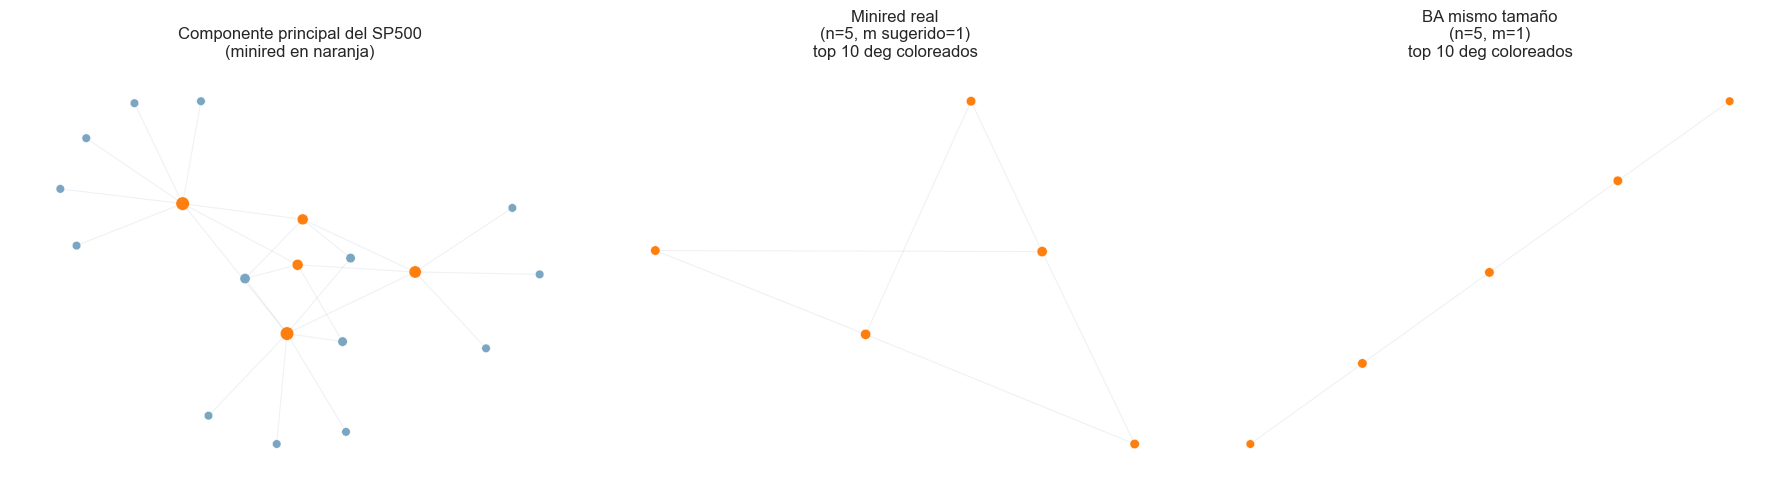

In [35]:
# comparar las tres redes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

draw_graph(
    axes[0],
    G_real,
    "Componente principal del SP500\n(minired en naranja)",
    highlight_nodes=mini_real.nodes(),
)

draw_graph(
    axes[1],
    mini_real,
    f"Minired real\n(n={mini_real.number_of_nodes()}, m sugerido={m})\ntop 10 deg coloreados",
    highlight_nodes=ranked_hubs,
)

# hubs de la red ba
top_ba_same = [node for node, _ in sorted(G_ba_same.degree(), key=lambda x: x[1], reverse=True)[:10]]
draw_graph(
    axes[2],
    G_ba_same,
    f"BA mismo tamaño\n(n={G_ba_same.number_of_nodes()}, m={m})\ntop 10 deg coloreados",
    highlight_nodes=top_ba_same,
)

plt.tight_layout()
plt.show()


# 2

- Grafica la distribución de grados junto con una función $C k^\alpha$ que mejor lo ajuste para ambas redes.

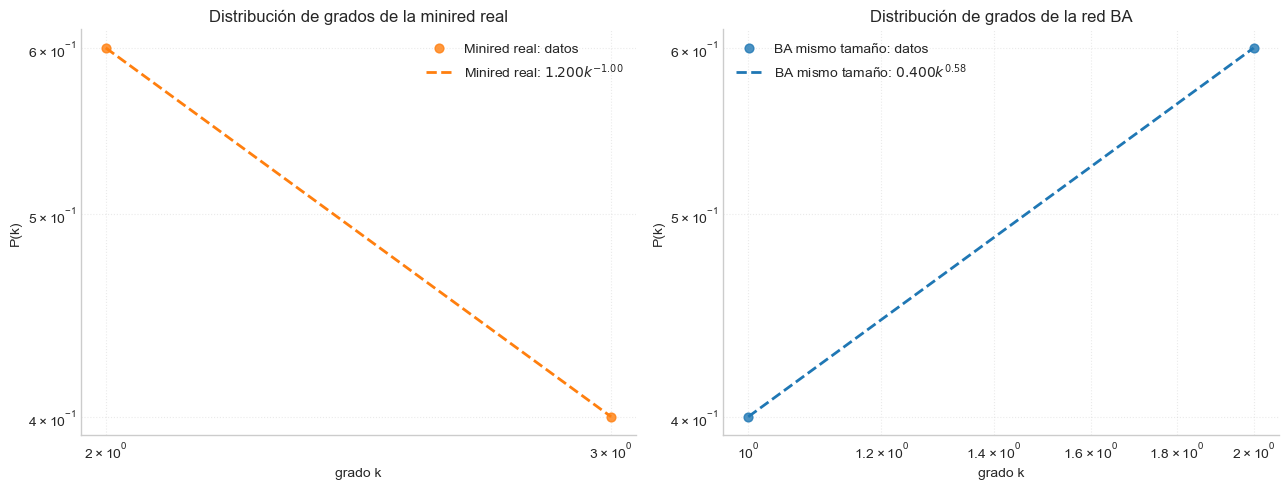

In [43]:
# comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_degree_distribution(axes[0], mini_real, "Minired real", "tab:orange")
axes[0].set_title("Distribución de grados de la minired real")
axes[0].legend()

plot_degree_distribution(axes[1], G_ba_same, "BA mismo tamaño", "tab:blue")
axes[1].set_title("Distribución de grados de la red BA")
axes[1].legend()

plt.tight_layout()
plt.show()

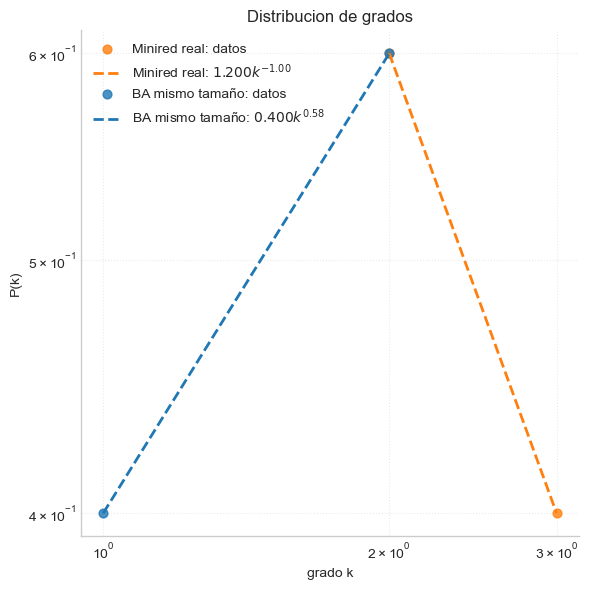

In [44]:
fig, ax = plt.subplots(figsize=(6, 6))

plot_degree_distribution(ax, mini_real, "Minired real", "tab:orange")
plot_degree_distribution(ax, G_ba_same, "BA mismo tamaño", "tab:blue")

ax.set_title("Distribucion de grados")
ax.legend()

plt.tight_layout()
plt.show()


# 3

- ¿Qué diferencia hay entre la red real y la red generada?

Son muy pocos nodos, son 5, y no hay ninguna triada.

In [38]:
# tabla de comparacion local
comparison_same_size = summary_df.loc[["Minired real", "BA mismo tamaño"]]
comparison_same_size

,nodos,aristas,grado medio,densidad,clustering medio,distancia media,C,alpha
red,,,,,,,,
Minired real,5,6,2.4,0.6,0.0,1.4,1.2,-1.000
BA mismo tamaño,5,4,1.6,0.4,0.0,2.0,0.4,0.585


# 4

- Utiliza la red como red inicial y genera una red con una mayor cantidad de nodos

Tomé como tamaño grande el mismo número de nodos de la componente principal del SP500 ($n=19$). Asi puedo ver que pasa cuando la minired de empresas lideres en tecnologia crece hasta incorporar firmas mas perifericas del mismo bloque, como energia, salud o consumo digital, pero manteniendo el mecanismo de apego preferencial.

,nodos,aristas,grado medio,densidad,clustering medio,distancia media,C,alpha
red,,,,,,,,
Componente principal SP500,19,24,2.526,0.140,0.0,2.409,0.295,-0.831
BA creciendo desde la minired,19,20,2.105,0.117,0.0,2.807,0.431,-1.228


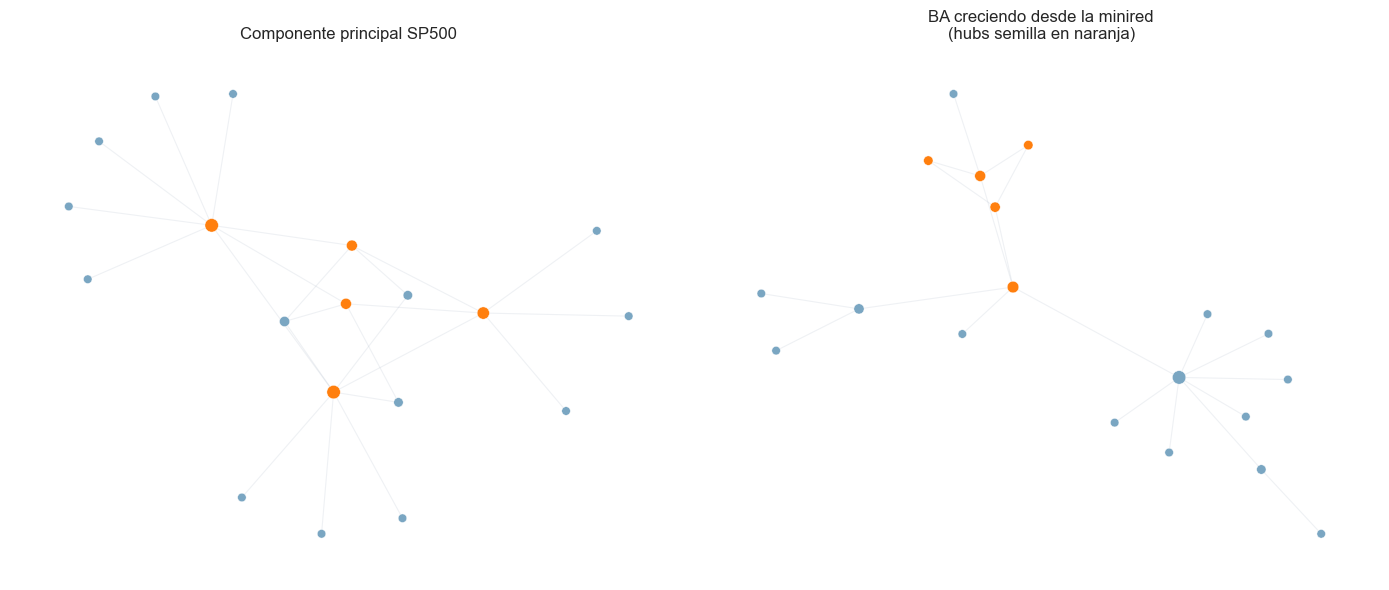

In [39]:
# comparar con la componente principal
comparison_full_size = summary_df.loc[["Componente principal SP500", "BA creciendo desde la minired"]]
display(comparison_full_size)

# hubs de la minired
top_mini_nodes = [node for node, _ in sorted(mini_real.degree(), key=lambda x: x[1], reverse=True)[:10]]
top_seed_nodes = [seed_mapping[node] for node in top_mini_nodes]

# red real contra red crecida
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_graph(axes[0], G_real, "Componente principal SP500", highlight_nodes=ranked_hubs)
draw_graph(
    axes[1],
    G_ba_grown,
    "BA creciendo desde la minired\n(hubs semilla en naranja)",
    highlight_nodes=top_seed_nodes,
)
plt.tight_layout()
plt.show()


# 5

- ¿Los nodos de mayor grado de la minired siguen teniendo grado alto en la red generada?

En general si. Los nodos semilla mas fuertes siguen apareciendo arriba en el ranking final, sobre todo NVDA, AMD y MSFT. Eso encaja con la intuicion del mercado: cuando una empresa ya ocupa una posicion central dentro del bloque tecnologico, es mas facil que nuevas relaciones se acumulen alrededor de ella.

In [40]:
# ranking final por grado
grown_degree_ranking = [node for node, _ in sorted(G_ba_grown.degree(), key=lambda x: x[1], reverse=True)]

# seguir los hubs iniciales
hub_retention_df = pd.DataFrame(
    {
        "nodo original": top_mini_nodes,
        "grado en la minired": [mini_real.degree(node) for node in top_mini_nodes],
        "grado en la red crecida": [G_ba_grown.degree(seed_mapping[node]) for node in top_mini_nodes],
        "posición en ranking final": [grown_degree_ranking.index(seed_mapping[node]) + 1 for node in top_mini_nodes],
    }
).sort_values("posición en ranking final")

hub_retention_df

,nodo original,grado en la minired,grado en la red crecida,posición en ranking final
3,PLTR,2,5,2
0,MSFT,3,4,3
1,AMZN,3,3,4
2,AMD,2,2,6
4,NVDA,2,2,7


# 6

- Grafica la distribución de grados junto con una función $C k^\alpha$ que mejor lo ajuste.

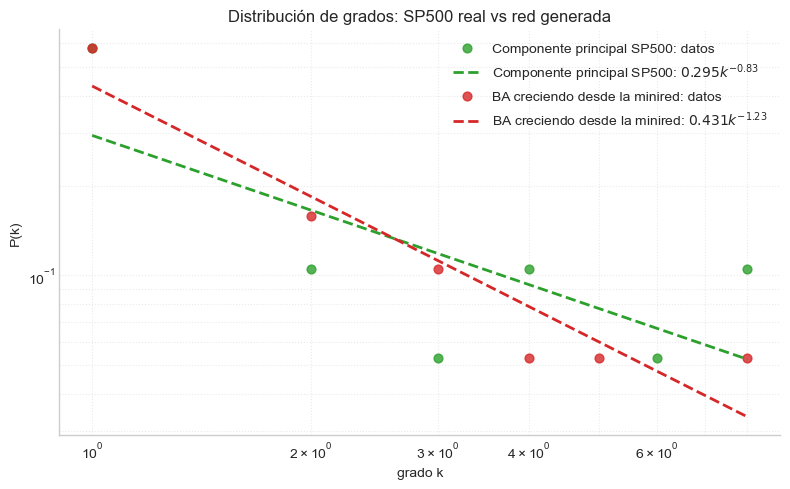

In [41]:
# comparar la cola de grados
fig, ax = plt.subplots(figsize=(8, 5))

plot_degree_distribution(ax, G_real, "Componente principal SP500", "tab:green")
plot_degree_distribution(ax, G_ba_grown, "BA creciendo desde la minired", "tab:red")

ax.set_title("Distribución de grados: SP500 real vs red generada")
ax.legend()
plt.tight_layout()
plt.show()

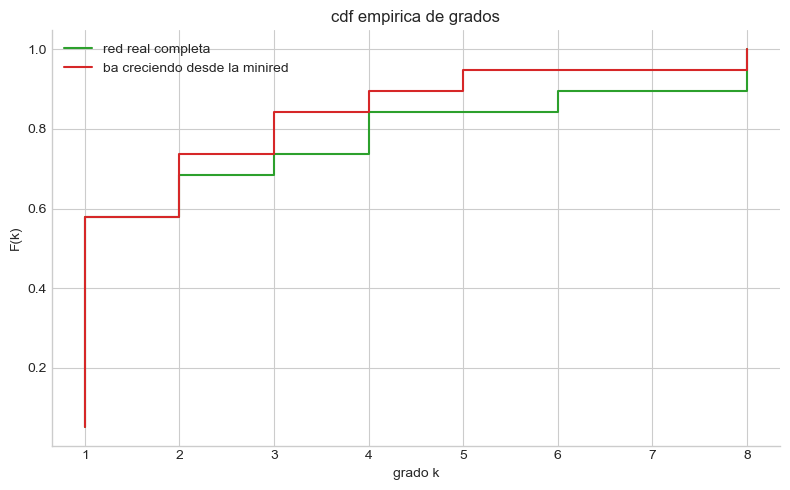

In [45]:
# grados de cada red
deg_real = np.array([d for _, d in G_real.degree()])
deg_ba = np.array([d for _, d in G_ba_grown.degree()])

# cdf empirica
def ecdf(x):
    x = np.sort(np.asarray(x))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x_real, y_real = ecdf(deg_real)
x_ba, y_ba = ecdf(deg_ba)

# graficar cdfs
fig, ax = plt.subplots(figsize=(8, 5))

ax.step(x_real, y_real, where="post", color="tab:green", label="red real completa")
ax.step(x_ba, y_ba, where="post", color="tab:red", label="ba creciendo desde la minired")

ax.set_xlabel("grado k")
ax.set_ylabel("F(k)")
ax.set_title("cdf empirica de grados")
ax.legend()

plt.tight_layout()
plt.show()


La red generada desde la minired reproduce una idea importante del SP500: una gran parte de la atencion se concentra en pocas empresas del nucleo tecnologico, en especial NVDA, MSFT, AMZN, AMD y PLTR. En ese sentido, el modelo de Barabasi-Albert si captura la tendencia a que los nodos que empiezan siendo centrales sigan acumulando conexiones.